In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
sns.set_theme()
gc.enable()

In [2]:
pos_data=pd.read_csv("POS_CASH_balance.csv")
pos_data.shape

(10001358, 8)

In [3]:
pos_data.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [4]:
pos_data.isnull().sum()

SK_ID_PREV                   0
SK_ID_CURR                   0
MONTHS_BALANCE               0
CNT_INSTALMENT           26071
CNT_INSTALMENT_FUTURE    26087
NAME_CONTRACT_STATUS         0
SK_DPD                       0
SK_DPD_DEF                   0
dtype: int64

In [5]:
'''
curr_prev_table stores the unique mapping of previous loans to current loans as a dataframe
'''
curr_prev_table=pos_data[['SK_ID_CURR', 'SK_ID_PREV']].drop_duplicates()
curr_prev_table.head()

,SK_ID_CURR,SK_ID_PREV
0,182943,1803195
1,367990,1715348
2,397406,1784872
3,269225,1903291
4,334279,2341044


### Aggregation Based on SK_ID_PREV

In [6]:
group=pos_data.groupby(by='SK_ID_PREV')

In [7]:
pos_agg=group.agg(func={'CNT_INSTALMENT':  ['min', 'max'], 'SK_ID_PREV': 'count', 
                'SK_DPD': 'max', 'SK_DPD_DEF': 'max'})
pos_agg.head()

CNT_INSTALMENT       SK_ID_PREV SK_DPD SK_DPD_DEF
                      min   max      count    max        max
SK_ID_PREV                                                  
1000001               2.0  12.0          3      0          0
1000002               4.0   6.0          5      0          0
1000003              12.0  12.0          4      0          0
1000004               7.0  10.0          8      0          0
1000005              10.0  10.0         11      0          0

In [8]:
pos_agg.shape

(936325, 5)

In [9]:
'''
renaming columns appropriatley and flattent the dataframe
'''
pos_agg.columns=pd.Index(['_'.join(val) for val in pos_agg.columns.to_flat_index()])
pos_agg.reset_index(inplace=True)
pos_agg.head()

,SK_ID_PREV,CNT_INSTALMENT_min,CNT_INSTALMENT_max,SK_ID_PREV_count,SK_DPD_max,SK_DPD_DEF_max
0,1000001,2.0,12.0,3,0,0
1,1000002,4.0,6.0,5,0,0
2,1000003,12.0,12.0,4,0,0
3,1000004,7.0,10.0,8,0,0
4,1000005,10.0,10.0,11,0,0


In [10]:
'''
adding INSTALMENT_REDUCTION_PCT
'''
pos_agg['INSTALMENT_REDUCTION_PCT']=(pos_agg['CNT_INSTALMENT_max']-pos_agg['CNT_INSTALMENT_min'])*100/pos_agg['CNT_INSTALMENT_max']
pos_agg.head()

,SK_ID_PREV,CNT_INSTALMENT_min,CNT_INSTALMENT_max,SK_ID_PREV_count,SK_DPD_max,SK_DPD_DEF_max,INSTALMENT_REDUCTION_PCT
0,1000001,2.0,12.0,3,0,0,83.333333
1,1000002,4.0,6.0,5,0,0,33.333333
2,1000003,12.0,12.0,4,0,0,0.000000
3,1000004,7.0,10.0,8,0,0,30.000000
4,1000005,10.0,10.0,11,0,0,0.000000


#### Aggregating MONTH_BALANCE AND NAME_CONTRACT_STATUS

In [11]:
'''
temp will contain the indices of the max month balance corresponding to each previous loan (recent most entry).
the indices will be according to the main data(pos_data). Using temp as index the rows can be accessed that tells the recent most
entry for the previous loan. That row is used to extract the recent most status of the contract
Lastly, data is merged to update pos_agg to obtain the final table
'''
temp=group['MONTHS_BALANCE'].idxmax()
temp2=pos_data.loc[temp, ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'NAME_CONTRACT_STATUS']]
pos_agg=pd.merge(left=temp2, right=pos_agg, on='SK_ID_PREV')
pos_agg.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,NAME_CONTRACT_STATUS,CNT_INSTALMENT_min,CNT_INSTALMENT_max,SK_ID_PREV_count,SK_DPD_max,SK_DPD_DEF_max,INSTALMENT_REDUCTION_PCT
0,1000001,158271,-8,Completed,2.0,12.0,3,0,0,83.333333
1,1000002,101962,-50,Completed,4.0,6.0,5,0,0,33.333333
2,1000003,252457,-1,Active,12.0,12.0,4,0,0,0.000000
3,1000004,260094,-22,Completed,7.0,10.0,8,0,0,30.000000
4,1000005,176456,-46,Completed,10.0,10.0,11,0,0,0.000000


In [12]:
pos_agg.shape

(936325, 10)

### Agregating Based on SK_ID_CURR (main aggregation)

In [13]:
pos_agg.isnull().sum()

SK_ID_PREV                    0
SK_ID_CURR                    0
MONTHS_BALANCE                0
NAME_CONTRACT_STATUS          0
CNT_INSTALMENT_min          890
CNT_INSTALMENT_max          890
SK_ID_PREV_count              0
SK_DPD_max                    0
SK_DPD_DEF_max                0
INSTALMENT_REDUCTION_PCT    890
dtype: int64

In [18]:
'''
renamig columns accordingly
'''
pos_agg.rename(columns={'CNT_INSTALMENT_max': 'ORIGINAL_INSTALMENTS', 'CNT_INSTALMENT_min': 'ACTUAL_INSTALMENTS',
                        'SK_DPD_max': 'DPD', 'SK_DPD_DEF_max': 'DPD_DEF', 'SK_ID_PREV': 'PREVIOUS_LOAN', 
                        'SK_ID_PREV_count': 'RECORD_count'}, inplace=True)
pos_agg.columns.sort_values()

Index(['ACTUAL_INSTALMENTS', 'DPD', 'DPD_DEF', 'INSTALMENT_REDUCTION_PCT',
       'MONTHS_BALANCE', 'NAME_CONTRACT_STATUS', 'ORIGINAL_INSTALMENTS',
       'PREVIOUS_LOAN', 'RECORD_count', 'SK_ID_CURR'],
      dtype='object')

In [30]:
'''
aggregating step
'''
pos_agg_2=pos_agg.groupby(by='SK_ID_CURR').agg(func={'ACTUAL_INSTALMENTS': ['min', 'max', 'median', 'sum'],
                                                     'ORIGINAL_INSTALMENTS': ['min', 'max', 'median', 'sum'],
                                                     'RECORD_count': ['min', 'max', 'median', 'sum'],
                                                     'INSTALMENT_REDUCTION_PCT': ['min', 'max', 'median'],
                                                     'MONTHS_BALANCE': ['min', 'max', 'median'],
                                                     'DPD': 'sum', 'DPD_DEF': 'sum',
                                                     'PREVIOUS_LOAN': 'count'})
pos_agg_2.columns=pd.Index(['_'.join(val) for val in pos_agg_2.columns.to_flat_index()])
pos_agg_2.reset_index(inplace=True)
pos_agg_2.shape

(337252, 22)

In [33]:
'''
adding target column
<main_data_id_target> contains target for each current loan
'''
main_data_id_target=pd.read_csv('application_train.csv',usecols=['SK_ID_CURR', 'TARGET']) 
pos_agg_target=pd.merge(left=pos_agg_2, right=main_data_id_target, on='SK_ID_CURR')
pos_agg_target.shape

(289444, 23)

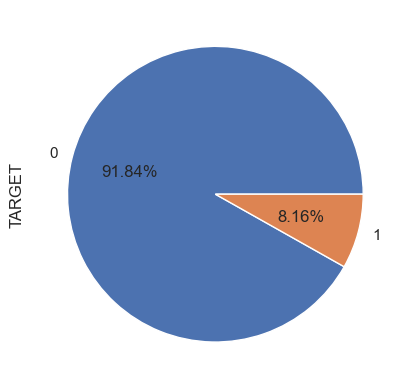

In [34]:
'''
distribution of target in the aggregated bureau data
'''
pos_agg_target['TARGET'].value_counts().plot.pie(autopct='%1.2f%%');

In [35]:
pos_agg_target.isnull().sum()

SK_ID_CURR                          0
ACTUAL_INSTALMENTS_min             24
ACTUAL_INSTALMENTS_max             24
ACTUAL_INSTALMENTS_median          24
ACTUAL_INSTALMENTS_sum              0
ORIGINAL_INSTALMENTS_min           24
ORIGINAL_INSTALMENTS_max           24
ORIGINAL_INSTALMENTS_median        24
ORIGINAL_INSTALMENTS_sum            0
RECORD_count_min                    0
RECORD_count_max                    0
RECORD_count_median                 0
RECORD_count_sum                    0
INSTALMENT_REDUCTION_PCT_min       24
INSTALMENT_REDUCTION_PCT_max       24
INSTALMENT_REDUCTION_PCT_median    24
MONTHS_BALANCE_min                  0
MONTHS_BALANCE_max                  0
MONTHS_BALANCE_median               0
DPD_sum                             0
DPD_DEF_sum                         0
PREVIOUS_LOAN_count                 0
TARGET                              0
dtype: int64

### Functions

In [36]:
def plot_hist_box(data, feature):
    '''
    takes dataframe and a feature name, outputs a plot with boxplot and histogram of the feature
    '''
    fig, axes=plt.subplots(ncols=2)
    fig.set_size_inches(w=10, h=5)
    axes[0].boxplot(data[feature].dropna());
    axes[0].set_xticklabels([feature]);
    axes[1].hist(data[feature]);
    return axes

In [37]:
def plot_hist_default_pct(feature, dataframe, bins):
    '''
    takes a dataframe, a feature name and number of bins. Plots a histogram of the feature such that binning is equal width, and the value is the deafult percentage of that bin.  
    '''
    df=dataframe.copy()
    df['%s_binned'%feature]=pd.qcut(df[feature], q=bins, precision=3, duplicates='drop')
    counts=df['%s_binned'%feature].value_counts()
    default_counts=df.loc[df['TARGET']==1, '%s_binned'%feature].value_counts()
    default_counts=default_counts*100/counts
    default_counts.sort_index(inplace=True)
    ax=plt.axes()
    ax.bar(default_counts.index.astype(str), default_counts.values)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title('Deafulters %% in %s'%feature)
    ax.set_xlabel('Category')
    ax.set_ylabel('Defaulter %')
    print(default_counts)


In [38]:
def calc_iqr(feature, data):
    '''
    takes a dataframe and a feature name, returns the the 1st quartile, 3rd quartile and the inter-quartile range
    '''
    q3=data[feature].quantile(0.75)
    q1=data[feature].quantile(0.25)
    iqr=q3-q1
    return q1, q3, iqr

In [39]:
def plot_kde_vs_target(feature, main_data):
    '''
    takes a dataframe and a feature name, plots two kernel density plots, one for deafulter customers and other of non-deafulter customers. plots nothing of the variance of the feature is zero. 
    '''
    paid=main_data[main_data['TARGET']==0][feature]
    defaulted=main_data[main_data['TARGET']==1][feature]
    sns.kdeplot(paid, label='Paid', color='b')
    sns.kdeplot(defaulted, label='Defaulted', color='r')
    plt.legend()

In [40]:
def plot_all_numeric_kde(main_data, numerical_features):
    '''
    takes a dataframe and an index of feature names, plots the kernel density plots of all features present in numerical_features   
    '''
    fig, axes=plt.subplots(numerical_features.shape[0])
    fig.set_size_inches(10, 4*numerical_features.shape[0])
    for i, feature in enumerate(numerical_features):
        q1, q3, iqr=calc_iqr(feature, main_data)
        plot_data=main_data.loc[(main_data[feature]>=q1-1.5*iqr) & (main_data[feature]<=q3+1.5*iqr), :]
        paid=plot_data[plot_data['TARGET']==0][feature]
        defaulted=plot_data[plot_data['TARGET']==1][feature]
        sns.kdeplot(paid, label='Paid', color='b', ax=axes[i])
        sns.kdeplot(defaulted, label='Defaulted', color='r', ax=axes[i])
        axes[i].legend()

In [41]:
def plot_pie_target(target_series, ax=None):
    if ax is None:
        ax=plt.axes()
    plot_data=target_series.value_counts()
    plot_data.rename(index={0: "Paid", 1: "Defaulted"}, inplace=True)
    ax.pie(x=plot_data.values, labels=plot_data.index, autopct='%1.1f%%')
    return ax



In [42]:
def median_vs_target(feature, data):
    '''
    takes a feature name and a dataframe. prints two values, one is median of non-defaulters while other is median of deafulters
    '''
    print('Median of %s with target=0 : %f'%(feature, data.loc[data['TARGET']==0, feature].median()))
    print('Median of %s with target=1 : %f'%(feature, data.loc[data['TARGET']==1, feature].median()))

In [ ]:
# plot_all_numeric_kde(pos_agg_target, pos_agg_target.columns)

In [44]:
numerical_features=pd.Index(['SK_ID_CURR', 'TARGET', 'ACTUAL_INSTALMENTS_sum', 'RECORD_count_max', 'RECORD_count_sum',
                             'INSTALMENT_REDUCTION_PCT_max', 'MONTHS_BALANCE_min', 'MONTHS_BALANCE_min', 
                             'MONTHS_BALANCE_median'])
numerical_frame=pos_agg_target[numerical_features].copy()
numerical_frame.shape

(289444, 9)